# Pretrained FastText 300 → 128 + CNN–LSTM cho full domain dài 32

Notebook huấn luyện mô hình DGA nhị phân trên `train_genAI.csv`, `val_genAI.csv`, `test_genAI.csv`.

Thiết kế:

- Giữ **full domain**, gồm subdomain, SLD và TLD.
- Lowercase, bỏ khoảng trắng biên và dấu chấm cuối FQDN.
- Giới hạn 32 ký tự; domain dài hơn 32 lấy **32 ký tự cuối** để ưu tiên giữ SLD và TLD.
- Khởi tạo bảng embedding ký tự 300 chiều từ pretrained `cc.en.300.bin`.
- Embedding 300 và projection tuyến tính `300 → 128` đều được fine-tune bằng nhãn `train_genAI`.
- Chín CNN kernel 2–10 nhận chuỗi `32 × 128`.
- LSTM 128 dùng packed sequence và lấy hidden state tại ký tự hợp lệ cuối cùng.
- Chọn checkpoint và threshold hoàn toàn bằng validation; test chỉ đánh giá sau khi chốt model.
- Khi xuất deployment bundle, embedding 300 và projection được **gộp chính xác** thành embedding 128. Worker không cần pretrained FastText hoặc lớp projection.

`cc.en.300.bin` là pretrained FastText do Facebook/Meta công bố. Google News 300 chiều là Word2Vec, không phải FastText.


## 1. Cấu trúc và phép gộp khi deployment

Trong lúc train:

```text
character id → Embedding(300) → Linear(300,128,bias=False)
                                    ├── CNN kernels 2–10
                                    └── packed LSTM 128
```

Sau khi train:

```python
folded_embedding = embedding_300 @ projection.weight.T
```

Do projection không có bias và không có activation ở giữa, phép gộp này giữ nguyên đầu ra về mặt toán học. Deployment chỉ còn `Embedding(128)`, giúp giảm artifact và loại bỏ phép chiếu khỏi inference.


## 2. Cài môi trường Colab

Chọn **Runtime → Change runtime type → GPU**. Pretrained FastText rất lớn; lần đầu tải và giải nén có thể mất nhiều thời gian và dung lượng. Sau khi tạo cache ma trận ký tự `41×300`, các lần chạy tiếp theo không cần load lại model FastText đầy đủ.


In [1]:
import sys
import subprocess

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'numpy>=1.26,<3',
    'pandas>=2,<3',
    'scikit-learn>=1.4,<2',
    'tqdm>=4.66,<5',
    'fasttext-community>=0.11.5,<0.12',
], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'numpy>=1.26,<3', 'pandas>=2,<3', 'scikit-learn>=1.4,<2', 'tqdm>=4.66,<5', 'fasttext-community>=0.11.5,<0.12'], returncode=0)

In [2]:
import gc
import gzip
import hashlib
import json
import os
import random
import shutil
import string
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from torch import nn
from torch.nn import functional as F
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Python:', sys.version.split()[0], '| torch:', torch.__version__, '| device:', DEVICE)
if DEVICE.type != 'cuda':
    raise RuntimeError('Hãy bật GPU trong Colab trước khi train bộ dữ liệu lớn.')


Python: 3.13.15 | torch: 2.11.0+cu130 | device: cuda


## 3. Drive, dữ liệu và cấu hình

Đặt dữ liệu theo cấu trúc:

```text
MyDrive/FastText_CNN_LSTM/
├── data/
│   ├── train_genAI.csv
│   ├── val_genAI.csv
│   └── test_genAI.csv
├── artifact/
└── runs/
```

Notebook mặc định tự tải `cc.en.300.bin.gz` từ máy chủ chính thức của FastText khi chưa có cả pretrained model lẫn character cache. Có thể đặt `AUTO_DOWNLOAD_FASTTEXT=False` nếu bạn muốn tự chép file vào Drive.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

ROOT = Path('/content/drive/MyDrive/FastText_CNN_LSTM')
DATA_DIR = ROOT / 'data'
ARTIFACT_DIR = ROOT / 'artifact'
RUN_DIR = ROOT / 'runs' / 'full_domain32_pretrained_fasttext300_project128_last_valid_v1'

TRAIN_PATH = DATA_DIR / 'train_genAI.csv'
VAL_PATH = DATA_DIR / 'val_genAI.csv'
TEST_PATH = DATA_DIR / 'test_genAI.csv'

FASTTEXT_BIN = ARTIFACT_DIR / 'cc.en.300.bin'
FASTTEXT_CHAR_CACHE = ARTIFACT_DIR / 'cc_en_300_character_matrix_v1.npz'
FASTTEXT_URL = 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz'
FASTTEXT_ARCHIVE = Path('/content/cc.en.300.bin.gz')
AUTO_DOWNLOAD_FASTTEXT = True

MAX_LEN = 32
PRETRAINED_DIM = 300
MODEL_DIM = 128
BATCH_SIZE = 64
MAX_EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5
LR_PATIENCE = 2
MIN_DELTA = 1e-4
NUM_WORKERS = 0
USE_AMP = True

ALPHABET = string.ascii_lowercase + string.digits + '.-_'
PAD_ID = 0
UNK_ID = 1
CHAR_TO_ID = {character: index + 2 for index, character in enumerate(ALPHABET)}
VOCAB_SIZE = len(CHAR_TO_ID) + 2

IMPLEMENTATION_DECISIONS = {
    'scope': 'pretrained_fasttext_full_domain32_project128_binary_genAI',
    'input': 'full_domain_lowercase_strip_trailing_dot_keep_rightmost_32',
    'max_len': MAX_LEN,
    'pretrained_source': 'Meta FastText cc.en.300.bin',
    'pretrained_embedding_dim': PRETRAINED_DIM,
    'model_embedding_dim': MODEL_DIM,
    'embedding_trainable': True,
    'projection': 'linear_300_to_128_without_bias',
    'lstm_sequence_handling': 'pack_padded_sequence_last_valid_hidden',
    'cnn_sequence_handling': 'zero_padded_length_32',
    'fusion': 'concatenate_9_cnn_global_max_vectors_and_lstm_last_valid_hidden',
    'checkpoint_selection': 'validation_tuned_f1',
    'deployment': 'fold_embedding_and_projection_to_128',
    'paper_exact_replica': False,
}

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
for split_name, path in [('train', TRAIN_PATH), ('val', VAL_PATH), ('test', TEST_PATH)]:
    if not path.is_file():
        raise FileNotFoundError(f'Thiếu {split_name}: {path}')

print('Data:', DATA_DIR)
print('Output:', RUN_DIR)
print('Vocab size:', VOCAB_SIZE, '| alphabet:', ALPHABET)


Mounted at /content/drive
Data: /content/drive/MyDrive/FastText_CNN_LSTM/data
Output: /content/drive/MyDrive/FastText_CNN_LSTM/runs/full_domain32_pretrained_fasttext300_project128_last_valid_v1
Vocab size: 41 | alphabet: abcdefghijklmnopqrstuvwxyz0123456789.-_


## 4. Chuẩn bị ma trận pretrained FastText 41×300

Chỉ 39 vector ký tự được lấy từ model lớn. `PAD` là vector 0; `UNK` là trung bình các vector ký tự hợp lệ. Cache nhỏ được lưu trên Drive để các lần chạy sau không cần load lại file `.bin` nhiều GB.

Pretrained FastText chỉ đóng vai trò khởi tạo. Embedding tiếp tục được cập nhật bằng supervised training trên `train_genAI`.


In [4]:
def sha256_file(path, block_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(block_size), b''):
            digest.update(block)
    return digest.hexdigest()


def download_with_progress(url, destination):
    request = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(request) as response:
        total = int(response.headers.get('Content-Length', 0))
        with destination.open('wb') as output, tqdm(
            total=total,
            unit='B',
            unit_scale=True,
            desc='Download FastText',
        ) as progress:
            while True:
                block = response.read(8 * 1024 * 1024)
                if not block:
                    break
                output.write(block)
                progress.update(len(block))


if FASTTEXT_CHAR_CACHE.is_file():
    with np.load(FASTTEXT_CHAR_CACHE, allow_pickle=False) as cache:
        pretrained_matrix = cache['matrix'].astype(np.float32)
        fasttext_provenance_json = str(cache['provenance_json'].item())
    fasttext_provenance = json.loads(fasttext_provenance_json)
    if pretrained_matrix.shape != (VOCAB_SIZE, PRETRAINED_DIM):
        raise ValueError(f'FastText cache sai shape: {pretrained_matrix.shape}')
    if not np.isfinite(pretrained_matrix).all():
        raise ValueError('FastText cache có NaN/Inf')
    if not np.array_equal(
        pretrained_matrix[PAD_ID], np.zeros(PRETRAINED_DIM, dtype=np.float32)
    ):
        raise ValueError('PAD vector trong cache không bằng 0')
    print('Dùng character cache:', FASTTEXT_CHAR_CACHE)
else:
    if not FASTTEXT_BIN.is_file():
        if not AUTO_DOWNLOAD_FASTTEXT:
            raise FileNotFoundError(
                f'Thiếu {FASTTEXT_BIN}; hãy chép cc.en.300.bin vào Drive '
                'hoặc bật AUTO_DOWNLOAD_FASTTEXT.'
            )
        if not FASTTEXT_ARCHIVE.is_file():
            download_with_progress(FASTTEXT_URL, FASTTEXT_ARCHIVE)

        print('Giải nén FastText vào Drive; bước này có thể lâu...')
        temporary_bin = FASTTEXT_BIN.with_name(FASTTEXT_BIN.name + '.tmp')
        with gzip.open(FASTTEXT_ARCHIVE, 'rb') as source, temporary_bin.open('wb') as target:
            with tqdm(unit='B', unit_scale=True, desc='Extract FastText') as progress:
                while True:
                    block = source.read(8 * 1024 * 1024)
                    if not block:
                        break
                    target.write(block)
                    progress.update(len(block))
        os.replace(temporary_bin, FASTTEXT_BIN)

    import fasttext

    print('Loading pretrained FastText; RAM có thể tăng nhiều trong cell này...')
    pretrained_model = fasttext.load_model(str(FASTTEXT_BIN))
    if pretrained_model.get_dimension() != PRETRAINED_DIM:
        raise ValueError('Pretrained FastText phải có dimension=300')

    pretrained_matrix = np.zeros((VOCAB_SIZE, PRETRAINED_DIM), dtype=np.float32)
    for character, index in CHAR_TO_ID.items():
        pretrained_matrix[index] = pretrained_model.get_word_vector(character)
    pretrained_matrix[UNK_ID] = pretrained_matrix[2:].mean(axis=0)

    if not np.isfinite(pretrained_matrix).all():
        raise ValueError('Pretrained FastText sinh vector NaN/Inf')

    fasttext_provenance = {
        'source': 'Meta FastText cc.en.300.bin',
        'url': FASTTEXT_URL,
        'source_file': FASTTEXT_BIN.name,
        'source_size_bytes': FASTTEXT_BIN.stat().st_size,
        'characters': ALPHABET,
        'lookup': 'get_word_vector(character)',
        'dimension': PRETRAINED_DIM,
    }
    fasttext_provenance_json = json.dumps(
        fasttext_provenance, sort_keys=True, ensure_ascii=False
    )
    cache_temp = FASTTEXT_CHAR_CACHE.with_name(FASTTEXT_CHAR_CACHE.stem + '.tmp.npz')
    np.savez_compressed(
        cache_temp,
        matrix=pretrained_matrix,
        provenance_json=fasttext_provenance_json,
    )
    os.replace(cache_temp, FASTTEXT_CHAR_CACHE)

    del pretrained_model
    gc.collect()
    print('Đã lưu character cache:', FASTTEXT_CHAR_CACHE)

print('Pretrained character matrix:', pretrained_matrix.shape)
print('Vector norm mean:', float(np.linalg.norm(pretrained_matrix[2:], axis=1).mean()))
print('Provenance:', fasttext_provenance)


Download FastText:   0%|          | 0.00/4.50G [00:00<?, ?B/s]

Giải nén FastText vào Drive; bước này có thể lâu...


Extract FastText: 0.00B [00:00, ?B/s]

Loading pretrained FastText; RAM có thể tăng nhiều trong cell này...
Đã lưu character cache: /content/drive/MyDrive/FastText_CNN_LSTM/artifact/cc_en_300_character_matrix_v1.npz
Pretrained character matrix: (41, 300)
Vector norm mean: 0.9743589758872986
Provenance: {'source': 'Meta FastText cc.en.300.bin', 'url': 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz', 'source_file': 'cc.en.300.bin', 'source_size_bytes': 7237176312, 'characters': 'abcdefghijklmnopqrstuvwxyz0123456789.-_', 'lookup': 'get_word_vector(character)', 'dimension': 300}


## 5. Đọc và làm sạch dữ liệu

Conflict, duplicate và overlap được kiểm tra trên full domain đã normalize. Thứ tự ưu tiên là train → validation → test. Notebook không sửa file CSV nguồn.


In [5]:
def normalize_domain(domain):
    if not isinstance(domain, str):
        return ''
    return domain.strip().lower().rstrip('.')


def load_split(path, split_name):
    frame = pd.read_csv(
        path,
        usecols=['domain_name', 'label'],
        dtype={'domain_name': 'string', 'label': 'string'},
        encoding='utf-8-sig',
    )
    if frame[['domain_name', 'label']].isna().any().any():
        raise ValueError(f'{split_name}: có domain/label rỗng')
    if not frame['label'].isin(['0', '1']).all():
        raise ValueError(f'{split_name}: label phải là 0/1')

    frame['source_domain'] = frame['domain_name'].astype(str).str.strip()
    frame['normalized_domain'] = frame['source_domain'].map(normalize_domain)
    frame['label'] = frame['label'].astype('int8')

    empty_count = int(frame.normalized_domain.eq('').sum())
    if empty_count:
        print(split_name, '| bỏ domain rỗng:', empty_count)
        frame = frame.loc[frame.normalized_domain.ne('')].copy()

    print(split_name, 'gốc:', len(frame),
          '| benign:', int((frame.label == 0).sum()),
          '| DGA:', int((frame.label == 1).sum()))
    return frame[['source_domain', 'normalized_domain', 'label']]


def clean_split(frame, split_name, seen_domains):
    conflicts = frame.groupby('normalized_domain', sort=False)['label'].nunique()
    conflict_domains = set(conflicts.index[conflicts > 1])
    if conflict_domains:
        print(split_name, '| nhãn mâu thuẫn, ví dụ:', sorted(conflict_domains)[:10])

    before = len(frame)
    frame = frame.loc[~frame.normalized_domain.isin(conflict_domains)].copy()
    dropped_conflict = before - len(frame)

    before = len(frame)
    frame = frame.loc[~frame.normalized_domain.isin(seen_domains)].copy()
    dropped_overlap = before - len(frame)

    before = len(frame)
    frame = frame.drop_duplicates(subset='normalized_domain', keep='first').reset_index(drop=True)
    dropped_duplicate = before - len(frame)

    if frame.empty or frame.label.nunique() != 2:
        raise ValueError(f'{split_name}: sau làm sạch cần có đủ hai lớp')

    print(split_name, 'sau làm sạch:', len(frame),
          '| bỏ conflict:', dropped_conflict,
          '| bỏ overlap:', dropped_overlap,
          '| bỏ duplicate:', dropped_duplicate)
    return frame


train_df = load_split(TRAIN_PATH, 'train')
val_df = load_split(VAL_PATH, 'val')
test_df = load_split(TEST_PATH, 'test')

train_df = clean_split(train_df, 'train', set())
train_domains = set(train_df.normalized_domain)
val_df = clean_split(val_df, 'val', train_domains)
val_domains = set(val_df.normalized_domain)
test_df = clean_split(test_df, 'test', train_domains | val_domains)

assert not (train_domains & val_domains)
assert not (set(test_df.normalized_domain) & (train_domains | val_domains))

data_hashes = {
    split_name: sha256_file(path)
    for split_name, path in [('train', TRAIN_PATH), ('val', VAL_PATH), ('test', TEST_PATH)]
}
print('SHA-256 nguồn:', data_hashes)


train gốc: 986316 | benign: 730168 | DGA: 256148
val gốc: 123290 | benign: 91272 | DGA: 32018
test gốc: 123293 | benign: 91273 | DGA: 32020
train | nhãn mâu thuẫn, ví dụ: ['bettertogether.net']
train sau làm sạch: 986314 | bỏ conflict: 2 | bỏ overlap: 0 | bỏ duplicate: 0
val sau làm sạch: 123289 | bỏ conflict: 0 | bỏ overlap: 1 | bỏ duplicate: 0
test sau làm sạch: 123291 | bỏ conflict: 0 | bỏ overlap: 2 | bỏ duplicate: 0
SHA-256 nguồn: {'train': '9fdd6a731b9792b6da03f107daa548844f44c87ae3e2aead5f709d45ac123363', 'val': 'be245d1b0c12e2b87f550bf5cb552d835c1f3b3c9ec1c4ceecbd9cb806183131', 'test': 'fb3250cc3e9a860724ad71a3a72d082e5213e4280b492f23523d4557814bea86'}


## 6. Mã hóa full domain thành chuỗi 32 ký tự

Domain dài hơn 32 lấy phần bên phải bằng `domain[-32:]`. Độ dài thật sau khi cắt được lưu riêng để packed LSTM bỏ qua padding.


In [6]:
def encode_domains(domains):
    token_ids = np.zeros((len(domains), MAX_LEN), dtype=np.uint8)
    lengths = np.zeros(len(domains), dtype=np.int64)
    truncated = 0
    unknown = 0

    for row, domain in enumerate(tqdm(domains, desc='Encode full domain', leave=False)):
        text = str(domain)
        truncated += len(text) > MAX_LEN
        clipped = text[-MAX_LEN:]
        lengths[row] = len(clipped)
        for column, character in enumerate(clipped):
            token = CHAR_TO_ID.get(character, UNK_ID)
            token_ids[row, column] = token
            unknown += token == UNK_ID

    if np.any(lengths <= 0):
        raise ValueError('Có domain rỗng sau normalize')
    return token_ids, lengths, {
        'truncated_domains': int(truncated),
        'truncated_percent': float(100 * truncated / max(len(domains), 1)),
        'unknown_characters': int(unknown),
        'mean_length': float(lengths.mean()),
        'max_observed_length_after_clip': int(lengths.max()),
        'truncation': 'keep_rightmost_32',
    }


train_ids, train_lengths, train_encoding_report = encode_domains(train_df.normalized_domain)
val_ids, val_lengths, val_encoding_report = encode_domains(val_df.normalized_domain)
test_ids, test_lengths, test_encoding_report = encode_domains(test_df.normalized_domain)

train_y = train_df.label.to_numpy(dtype=np.float32)
val_y = val_df.label.to_numpy(dtype=np.float32)
test_y = test_df.label.to_numpy(dtype=np.float32)

encoding_report = {
    'train': train_encoding_report,
    'val': val_encoding_report,
    'test': test_encoding_report,
}
print(json.dumps(encoding_report, ensure_ascii=False, indent=2))


Encode full domain:   0%|          | 0/986314 [00:00<?, ?it/s]

Encode full domain:   0%|          | 0/123289 [00:00<?, ?it/s]

Encode full domain:   0%|          | 0/123291 [00:00<?, ?it/s]

{
  "train": {
    "truncated_domains": 7754,
    "truncated_percent": 0.7861593772368637,
    "unknown_characters": 0,
    "mean_length": 15.346840864065602,
    "max_observed_length_after_clip": 32,
    "truncation": "keep_rightmost_32"
  },
  "val": {
    "truncated_domains": 899,
    "truncated_percent": 0.7291810299377884,
    "unknown_characters": 0,
    "mean_length": 15.327928687879698,
    "max_observed_length_after_clip": 32,
    "truncation": "keep_rightmost_32"
  },
  "test": {
    "truncated_domains": 952,
    "truncated_percent": 0.7721569295406802,
    "unknown_characters": 0,
    "mean_length": 15.357471348273597,
    "max_observed_length_after_clip": 32,
    "truncation": "keep_rightmost_32"
  }
}


## 7. Dataset và model train-time

`Linear(300,128,bias=False)` giữ vector padding bằng 0. Packed LSTM sử dụng `lengths` trên CPU và trả về hidden state tại ký tự hợp lệ cuối cùng.


In [7]:
class DomainDataset(Dataset):
    def __init__(self, token_ids, lengths, labels):
        self.token_ids = torch.from_numpy(token_ids)
        self.lengths = torch.from_numpy(lengths)
        self.labels = torch.from_numpy(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.token_ids[index], self.lengths[index], self.labels[index]


class FastTextProjectedCNNLSTM32(nn.Module):
    def __init__(self, matrix):
        super().__init__()
        expected_shape = (VOCAB_SIZE, PRETRAINED_DIM)
        if matrix.shape != expected_shape:
            raise ValueError(f'Embedding shape {matrix.shape}, cần {expected_shape}')

        self.embedding = nn.Embedding.from_pretrained(
            torch.from_numpy(matrix.copy()),
            freeze=False,
            padding_idx=PAD_ID,
        )
        self.projection = nn.Linear(PRETRAINED_DIM, MODEL_DIM, bias=False)
        nn.init.orthogonal_(self.projection.weight)

        self.convs = nn.ModuleList([
            nn.Conv1d(MODEL_DIM, 256, kernel_size)
            for kernel_size in range(2, 11)
        ])
        self.cnn_bn = nn.BatchNorm1d(256 * 9)
        self.cnn_dropout = nn.Dropout(0.5)
        self.lstm = nn.LSTM(MODEL_DIM, 128, batch_first=True)
        self.lstm_dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(256 * 9 + 128, 1)

    def forward(self, token_ids, lengths):
        embedded_300 = self.embedding(token_ids)
        embedded_128 = self.projection(embedded_300)

        channel_first = embedded_128.transpose(1, 2)
        cnn_features = torch.cat([
            F.adaptive_max_pool1d(F.relu(conv(channel_first)), 1).squeeze(-1)
            for conv in self.convs
        ], dim=1)
        cnn_features = self.cnn_dropout(self.cnn_bn(cnn_features))

        safe_lengths = lengths.to(dtype=torch.long, device='cpu').clamp(1, MAX_LEN)
        packed = pack_padded_sequence(
            embedded_128,
            safe_lengths,
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)
        lstm_features = self.lstm_dropout(hidden[-1])

        fused = torch.cat([cnn_features, lstm_features], dim=1)
        return self.classifier(fused).squeeze(1)


def make_loader(token_ids, lengths, labels, shuffle=False):
    return DataLoader(
        DomainDataset(token_ids, lengths, labels),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == 'cuda'),
    )


train_loader = make_loader(train_ids, train_lengths, train_y, shuffle=True)
val_loader = make_loader(val_ids, val_lengths, val_y)
test_loader = make_loader(test_ids, test_lengths, test_y)

model = FastTextProjectedCNNLSTM32(pretrained_matrix).to(DEVICE)
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(model)
print('Trainable parameters:', f'{trainable_parameters:,}')

sample_ids = torch.from_numpy(train_ids[:2]).to(DEVICE, dtype=torch.long)
sample_lengths = torch.from_numpy(train_lengths[:2])
sample_logits = model(sample_ids, sample_lengths)
assert sample_logits.shape == (2,)

mean_train_length = float(train_lengths.mean())
projection_macs = MAX_LEN * PRETRAINED_DIM * MODEL_DIM
cnn_macs = sum(
    (MAX_LEN - kernel + 1) * MODEL_DIM * 256 * kernel
    for kernel in range(2, 11)
)
lstm_macs_mean = mean_train_length * 4 * 128 * (MODEL_DIM + 128)
lstm_macs_max = MAX_LEN * 4 * 128 * (MODEL_DIM + 128)

print('Projection MAC/domain:', f'{projection_macs:,.0f}')
print('CNN MAC/domain:', f'{cnn_macs:,.0f}')
print('Packed LSTM mean MAC/domain:', f'{lstm_macs_mean:,.0f}')
print('Train-time forward MAC/domain:',
      f'{projection_macs + cnn_macs + lstm_macs_mean + 2432:,.0f}')
print('Folded deployment MAC/domain:', f'{cnn_macs + lstm_macs_mean + 2432:,.0f}')
print('Worst-case folded MAC/domain:', f'{cnn_macs + lstm_macs_max + 2432:,.0f}')


FastTextProjectedCNNLSTM32(
  (embedding): Embedding(41, 300, padding_idx=0)
  (projection): Linear(in_features=300, out_features=128, bias=False)
  (convs): ModuleList(
    (0): Conv1d(128, 256, kernel_size=(2,), stride=(1,))
    (1): Conv1d(128, 256, kernel_size=(3,), stride=(1,))
    (2): Conv1d(128, 256, kernel_size=(4,), stride=(1,))
    (3): Conv1d(128, 256, kernel_size=(5,), stride=(1,))
    (4): Conv1d(128, 256, kernel_size=(6,), stride=(1,))
    (5): Conv1d(128, 256, kernel_size=(7,), stride=(1,))
    (6): Conv1d(128, 256, kernel_size=(8,), stride=(1,))
    (7): Conv1d(128, 256, kernel_size=(9,), stride=(1,))
    (8): Conv1d(128, 256, kernel_size=(10,), stride=(1,))
  )
  (cnn_bn): BatchNorm1d(2304, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (cnn_dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(128, 128, batch_first=True)
  (lstm_dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=2432, out_features=1, bias=True)
)
Trainable 

## 8. Huấn luyện

Mỗi epoch tìm threshold tối đa F1 trên validation. Checkpoint được chọn theo **validation tuned F1**, phù hợp với cách threshold được dùng khi triển khai. Test không tham gia scheduler, early stopping, checkpoint hoặc threshold.


In [8]:
def metrics_at_threshold(labels, probabilities, threshold):
    predicted = (probabilities >= threshold).astype(np.int8)
    return {
        'accuracy': float(accuracy_score(labels, predicted)),
        'precision': float(precision_score(labels, predicted, zero_division=0)),
        'recall': float(recall_score(labels, predicted, zero_division=0)),
        'f1': float(f1_score(labels, predicted, zero_division=0)),
        'confusion_matrix': confusion_matrix(labels, predicted, labels=[0, 1]).tolist(),
    }


def tune_f1_threshold(labels, probabilities):
    precision, recall, thresholds = precision_recall_curve(labels, probabilities)
    if len(thresholds) == 0:
        return 0.5, metrics_at_threshold(labels, probabilities, 0.5)
    f1_values = (
        2 * precision[:-1] * recall[:-1]
        / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    )
    best_index = int(np.argmax(f1_values))
    threshold = float(thresholds[best_index])
    return threshold, metrics_at_threshold(labels, probabilities, threshold)


criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=LR_PATIENCE, min_lr=1e-6
)
amp_enabled = USE_AMP and DEVICE.type == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)


def run_loader(loader, training, description):
    model.train(training)
    losses = 0.0
    count = 0
    collected_labels = []
    collected_probabilities = []

    with torch.set_grad_enabled(training):
        for token_ids, lengths, labels in tqdm(loader, desc=description, leave=False):
            token_ids = token_ids.to(DEVICE, dtype=torch.long, non_blocking=True)
            labels = labels.to(DEVICE, dtype=torch.float32, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type='cuda', enabled=amp_enabled):
                logits = model(token_ids, lengths)
                loss = criterion(logits, labels)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                collected_labels.append(labels.cpu().numpy())
                collected_probabilities.append(torch.sigmoid(logits.float()).cpu().numpy())

            losses += float(loss.item()) * len(labels)
            count += len(labels)

    average_loss = losses / max(count, 1)
    if training:
        return average_loss, None, None
    return average_loss, np.concatenate(collected_labels), np.concatenate(collected_probabilities)


def save_json(path, data):
    temporary = path.with_name(path.name + '.tmp')
    temporary.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')
    os.replace(temporary, path)


BEST_PATH = RUN_DIR / 'best_training_checkpoint.pt'
HISTORY_PATH = RUN_DIR / 'history.json'
history = []
best_val_f1 = -1.0
best_epoch = 0
stale = 0

for epoch in range(1, MAX_EPOCHS + 1):
    started = time.monotonic()
    train_loss, _, _ = run_loader(
        train_loader, True, f'Epoch {epoch}/{MAX_EPOCHS} train'
    )
    val_loss, val_labels, val_probabilities = run_loader(
        val_loader, False, f'Epoch {epoch}/{MAX_EPOCHS} validation'
    )
    val_threshold, val_tuned_metrics = tune_f1_threshold(
        val_labels, val_probabilities
    )
    val_metrics_05 = metrics_at_threshold(val_labels, val_probabilities, 0.5)
    scheduler.step(val_tuned_metrics['f1'])

    record = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_threshold': val_threshold,
        'val_metrics_0_5': val_metrics_05,
        'val_metrics_tuned': val_tuned_metrics,
        'learning_rate': optimizer.param_groups[0]['lr'],
        'seconds': time.monotonic() - started,
    }
    history.append(record)
    save_json(HISTORY_PATH, history)

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.5f} "
        f"val_loss={val_loss:.5f} th={val_threshold:.4f} "
        f"acc={val_tuned_metrics['accuracy']:.4f} "
        f"pre={val_tuned_metrics['precision']:.4f} "
        f"rec={val_tuned_metrics['recall']:.4f} "
        f"f1={val_tuned_metrics['f1']:.4f} "
        f"lr={optimizer.param_groups[0]['lr']:.2e} "
        f"sec={record['seconds']:.1f}",
        flush=True,
    )

    if val_tuned_metrics['f1'] > best_val_f1 + MIN_DELTA:
        best_val_f1 = val_tuned_metrics['f1']
        best_epoch = epoch
        stale = 0
        checkpoint = {
            'model_state_dict': {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            },
            'epoch': epoch,
            'best_val_f1': best_val_f1,
            'best_threshold': val_threshold,
            'preprocessing': {
                'input': 'full_domain_lowercase_strip_trailing_dot_keep_rightmost_32',
                'max_len': MAX_LEN,
                'truncation': 'rightmost',
                'alphabet': ALPHABET,
                'pad_id': PAD_ID,
                'unk_id': UNK_ID,
                'char_to_id': CHAR_TO_ID,
                'length': 'min(len(normalized_domain), 32)',
            },
            'model_config': {
                'type': 'FastTextProjectedCNNLSTM32',
                'pretrained_embedding_dim': PRETRAINED_DIM,
                'model_embedding_dim': MODEL_DIM,
                'projection': 'linear_without_bias',
                'cnn_kernels': list(range(2, 11)),
                'cnn_filters': 256,
                'lstm_hidden': 128,
                'dropout': 0.5,
                'lstm_sequence_handling': 'pack_padded_sequence_last_valid_hidden',
                'fusion': 'concat_cnn_pool_lstm_last_valid_hidden',
                'output': 'one_logit',
            },
            'source': {
                'csv_sha256': data_hashes,
                'fasttext_provenance': fasttext_provenance,
            },
            'implementation_decisions': IMPLEMENTATION_DECISIONS,
        }
        temporary = BEST_PATH.with_name(BEST_PATH.name + '.tmp')
        torch.save(checkpoint, temporary)
        os.replace(temporary, BEST_PATH)
        print('  → Đã lưu best checkpoint', flush=True)
    else:
        stale += 1

    if stale >= EARLY_STOPPING_PATIENCE:
        print('Early stopping sau epoch', epoch)
        break

print('Best epoch:', best_epoch, '| validation tuned F1:', round(best_val_f1, 6))


Epoch 1/30 train:   0%|          | 0/15412 [00:00<?, ?it/s]

Epoch 1/30 validation:   0%|          | 0/1927 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.16139 val_loss=0.11199 th=0.3300 acc=0.9628 pre=0.9444 rec=0.9104 f1=0.9271 lr=1.00e-03 sec=260.6
  → Đã lưu best checkpoint


Epoch 2/30 train:   0%|          | 0/15412 [00:00<?, ?it/s]

Epoch 2/30 validation:   0%|          | 0/1927 [00:00<?, ?it/s]

...

Epoch 29/30 validation:   0%|          | 0/1927 [00:00<?, ?it/s]

Epoch 29 | train_loss=0.04883 val_loss=0.06337 th=0.2628 acc=0.9814 pre=0.9693 rec=0.9587 f1=0.9639 lr=5.00e-04 sec=248.8
  → Đã lưu best checkpoint


Epoch 30/30 train:   0%|          | 0/15412 [00:00<?, ?it/s]

Epoch 30/30 validation:   0%|          | 0/1927 [00:00<?, ?it/s]

Epoch 30 | train_loss=0.04821 val_loss=0.05840 th=0.4565 acc=0.9818 pre=0.9727 rec=0.9569 f1=0.9647 lr=5.00e-04 sec=236.8
  → Đã lưu best checkpoint
Best epoch: 30 | validation tuned F1: 0.964717


## 9. Đường học validation


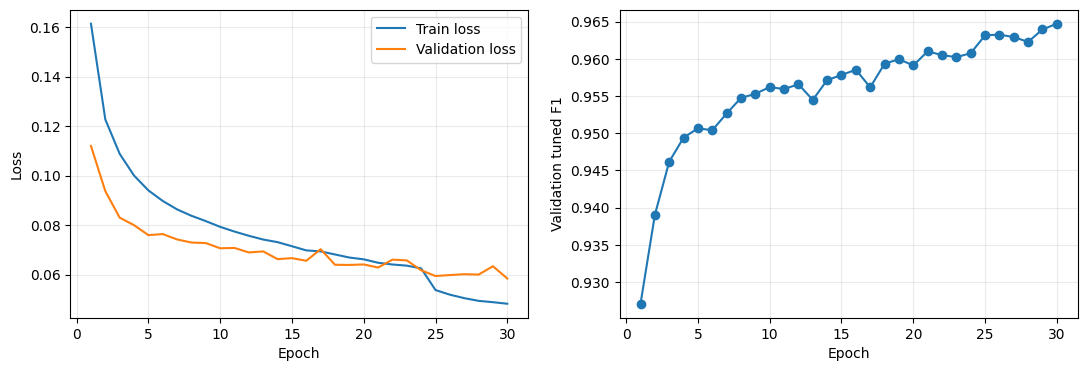

In [9]:
import matplotlib.pyplot as plt

history_frame = pd.DataFrame([
    {
        'epoch': item['epoch'],
        'train_loss': item['train_loss'],
        'val_loss': item['val_loss'],
        'val_f1_tuned': item['val_metrics_tuned']['f1'],
        'learning_rate': item['learning_rate'],
    }
    for item in history
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_frame.epoch, history_frame.train_loss, label='Train loss')
axes[0].plot(history_frame.epoch, history_frame.val_loss, label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history_frame.epoch, history_frame.val_f1_tuned, marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation tuned F1')
axes[1].grid(alpha=0.25)
plt.show()


## 10. Nạp best checkpoint và đánh giá test một lần


In [10]:
checkpoint = torch.load(BEST_PATH, map_location='cpu', weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'], strict=True)
model.to(DEVICE).eval()

best_threshold = float(checkpoint['best_threshold'])
val_loss, val_labels, val_probabilities = run_loader(
    val_loader, False, 'Best checkpoint validation'
)
val_metrics_05 = metrics_at_threshold(val_labels, val_probabilities, 0.5)
val_metrics_tuned = metrics_at_threshold(
    val_labels, val_probabilities, best_threshold
)

test_loss, test_labels, test_probabilities = run_loader(
    test_loader, False, 'Final test'
)
test_metrics_05 = metrics_at_threshold(test_labels, test_probabilities, 0.5)
test_metrics_tuned = metrics_at_threshold(
    test_labels, test_probabilities, best_threshold
)

print('Best epoch:', checkpoint['epoch'])
print('Best threshold từ validation:', best_threshold)
print('Validation @0.5:', val_metrics_05)
print('Validation @saved threshold:', val_metrics_tuned)
print('TEST loss:', test_loss)
print('TEST @0.5:', test_metrics_05)
print('TEST @validation threshold:', test_metrics_tuned)


Best checkpoint validation:   0%|          | 0/1927 [00:00<?, ?it/s]

Final test:   0%|          | 0/1927 [00:00<?, ?it/s]

Best epoch: 30
Best threshold từ validation: 0.4565006196498871
Validation @0.5: {'accuracy': 0.9816366423606323, 'precision': 0.9749992017625084, 'recall': 0.9537433238591998, 'f1': 0.9642541366679298, 'confusion_matrix': [[90489, 783], [1481, 30536]]}
Validation @saved threshold: {'accuracy': 0.9818231959055552, 'precision': 0.9726649311067369, 'recall': 0.9568978979916919, 'f1': 0.9647169959852003, 'confusion_matrix': [[90411, 861], [1380, 30637]]}
TEST loss: 0.06153524837348978
TEST @0.5: {'accuracy': 0.9807528530063022, 'precision': 0.9718596803972751, 'recall': 0.9534963615353383, 'f1': 0.9625904497658947, 'confusion_matrix': [[90388, 884], [1489, 30530]]}
TEST @validation threshold: {'accuracy': 0.9807934074668873, 'precision': 0.9691465459953799, 'recall': 0.956494581342328, 'f1': 0.9627790003143666, 'confusion_matrix': [[90297, 975], [1393, 30626]]}


## 11. Gộp embedding 300 và projection thành embedding 128

`FastTextProjectedCNNLSTM32` được dùng khi train. `FastTextCNNLSTM32Folded` là kiến trúc deployment. Cell kiểm tra logits của hai model trước khi lưu bundle.


In [11]:
class FastTextCNNLSTM32Folded(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, MODEL_DIM, padding_idx=PAD_ID)
        self.convs = nn.ModuleList([
            nn.Conv1d(MODEL_DIM, 256, kernel_size)
            for kernel_size in range(2, 11)
        ])
        self.cnn_bn = nn.BatchNorm1d(256 * 9)
        self.cnn_dropout = nn.Dropout(0.5)
        self.lstm = nn.LSTM(MODEL_DIM, 128, batch_first=True)
        self.lstm_dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(256 * 9 + 128, 1)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)

        channel_first = embedded.transpose(1, 2)
        cnn_features = torch.cat([
            F.adaptive_max_pool1d(F.relu(conv(channel_first)), 1).squeeze(-1)
            for conv in self.convs
        ], dim=1)
        cnn_features = self.cnn_dropout(self.cnn_bn(cnn_features))

        safe_lengths = lengths.to(dtype=torch.long, device='cpu').clamp(1, MAX_LEN)
        packed = pack_padded_sequence(
            embedded,
            safe_lengths,
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)
        lstm_features = self.lstm_dropout(hidden[-1])
        return self.classifier(
            torch.cat([cnn_features, lstm_features], dim=1)
        ).squeeze(1)


folded_model = FastTextCNNLSTM32Folded().to(DEVICE)
with torch.no_grad():
    folded_weight = model.embedding.weight @ model.projection.weight.T
    folded_weight[PAD_ID].zero_()
    folded_model.embedding.weight.copy_(folded_weight)
    folded_model.convs.load_state_dict(model.convs.state_dict())
    folded_model.cnn_bn.load_state_dict(model.cnn_bn.state_dict())
    folded_model.lstm.load_state_dict(model.lstm.state_dict())
    folded_model.classifier.load_state_dict(model.classifier.state_dict())

folded_model.eval()
model.eval()

verification_count = min(64, len(test_ids))
verification_ids = torch.from_numpy(test_ids[:verification_count]).to(
    DEVICE, dtype=torch.long
)
verification_lengths = torch.from_numpy(test_lengths[:verification_count])

with torch.inference_mode():
    original_logits = model(verification_ids, verification_lengths).float().cpu().numpy()
    folded_logits = folded_model(verification_ids, verification_lengths).float().cpu().numpy()

np.testing.assert_allclose(
    folded_logits,
    original_logits,
    rtol=1e-4,
    atol=1e-5,
)
print('Fold verification: PASSED')
print('Folded trainable parameters:',
      f'{sum(p.numel() for p in folded_model.parameters()):,}')


Fold verification: PASSED
Folded trainable parameters: 1,916,161


## 12. Xuất deployment bundle và báo cáo

`best_bundle.pt` chứa model đã gộp, threshold validation và toàn bộ preprocessing. Đây là file dùng cho testbed. `best_training_checkpoint.pt` được giữ để tiếp tục fine-tune kiến trúc 300→128 nếu cần.


In [12]:
deployment_bundle = {
    'model_state_dict': {
        key: value.detach().cpu().clone()
        for key, value in folded_model.state_dict().items()
    },
    'best_epoch': int(checkpoint['epoch']),
    'best_val_f1': float(checkpoint['best_val_f1']),
    'best_threshold': best_threshold,
    'preprocessing': checkpoint['preprocessing'],
    'model_config': {
        'type': 'FastTextCNNLSTM32Folded',
        'embedding_dim': MODEL_DIM,
        'pretrained_embedding_dim_during_training': PRETRAINED_DIM,
        'embedding_projection_folded': True,
        'cnn_kernels': list(range(2, 11)),
        'cnn_filters': 256,
        'lstm_hidden': 128,
        'dropout': 0.5,
        'lstm_sequence_handling': 'pack_padded_sequence_last_valid_hidden',
        'fusion': 'concat_cnn_pool_lstm_last_valid_hidden',
        'output': 'one_logit',
    },
    'source': checkpoint['source'],
    'implementation_decisions': checkpoint['implementation_decisions'],
    'validation_metrics_0_5': val_metrics_05,
    'validation_metrics_tuned': val_metrics_tuned,
    'test_metrics_0_5': test_metrics_05,
    'test_metrics_tuned': test_metrics_tuned,
}

bundle_path = RUN_DIR / 'best_bundle.pt'
bundle_temporary = bundle_path.with_name(bundle_path.name + '.tmp')
torch.save(deployment_bundle, bundle_temporary)
os.replace(bundle_temporary, bundle_path)

metrics_report = {
    'dataset': 'genAI_full_domain_train_val_test',
    'best_epoch': int(checkpoint['epoch']),
    'best_threshold_from_validation': best_threshold,
    'validation': {
        'loss': val_loss,
        'at_0_5': val_metrics_05,
        'at_tuned': val_metrics_tuned,
    },
    'test': {
        'loss': test_loss,
        'at_0_5': test_metrics_05,
        'at_tuned': test_metrics_tuned,
    },
    'encoding': encoding_report,
    'source_sha256': data_hashes,
    'fasttext_provenance': fasttext_provenance,
    'implementation_decisions': IMPLEMENTATION_DECISIONS,
    'training': {
        'seed': SEED,
        'batch_size': BATCH_SIZE,
        'max_epochs': MAX_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'amp': amp_enabled,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'checkpoint_selection': 'validation_tuned_f1',
    },
}

save_json(RUN_DIR / 'metrics.json', metrics_report)
pd.DataFrame({
    'source_domain': test_df.source_domain,
    'normalized_domain': test_df.normalized_domain,
    'encoded_suffix_32': [value[-MAX_LEN:] for value in test_df.normalized_domain],
    'label': test_y.astype(np.int8),
    'sequence_length': test_lengths,
    'dga_probability': test_probabilities,
    'pred_0_5': (test_probabilities >= 0.5).astype(np.int8),
    'pred_tuned': (test_probabilities >= best_threshold).astype(np.int8),
}).to_csv(RUN_DIR / 'test_predictions.csv', index=False)

print('Deployment bundle:', bundle_path)
print('Resume checkpoint:', BEST_PATH)
print('Metrics:', RUN_DIR / 'metrics.json')
print('History:', HISTORY_PATH)
print('Test predictions:', RUN_DIR / 'test_predictions.csv')


Deployment bundle: /content/drive/MyDrive/FastText_CNN_LSTM/runs/full_domain32_pretrained_fasttext300_project128_last_valid_v1/best_bundle.pt
Resume checkpoint: /content/drive/MyDrive/FastText_CNN_LSTM/runs/full_domain32_pretrained_fasttext300_project128_last_valid_v1/best_training_checkpoint.pt
Metrics: /content/drive/MyDrive/FastText_CNN_LSTM/runs/full_domain32_pretrained_fasttext300_project128_last_valid_v1/metrics.json
History: /content/drive/MyDrive/FastText_CNN_LSTM/runs/full_domain32_pretrained_fasttext300_project128_last_valid_v1/history.json
Test predictions: /content/drive/MyDrive/FastText_CNN_LSTM/runs/full_domain32_pretrained_fasttext300_project128_last_valid_v1/test_predictions.csv


## 13. Kiểm tra nạp lại deployment bundle


In [13]:
reloaded = torch.load(bundle_path, map_location='cpu', weights_only=True)
reloaded_model = FastTextCNNLSTM32Folded().to(DEVICE)
reloaded_model.load_state_dict(reloaded['model_state_dict'], strict=True)
reloaded_model.eval()


def predict_domains(domains):
    normalized = [normalize_domain(str(domain)) for domain in domains]
    if any(not value for value in normalized):
        raise ValueError('Có domain rỗng sau normalize')

    encoded, lengths, _ = encode_domains(normalized)
    token_tensor = torch.from_numpy(encoded).to(DEVICE, dtype=torch.long)
    length_tensor = torch.from_numpy(lengths)

    with torch.inference_mode():
        logits = reloaded_model(token_tensor, length_tensor)
        probabilities = torch.sigmoid(logits.float()).cpu().numpy()

    threshold = float(reloaded['best_threshold'])
    return pd.DataFrame({
        'domain': list(domains),
        'normalized_domain': normalized,
        'encoded_suffix_32': [value[-MAX_LEN:] for value in normalized],
        'probability': probabilities,
        'prediction': (probabilities >= threshold).astype(np.int8),
    })


sample_domains = test_df.source_domain.iloc[:8].tolist()
sample_predictions = predict_domains(sample_domains)

with torch.inference_mode():
    reference_probabilities = torch.sigmoid(
        folded_model(
            torch.from_numpy(test_ids[:len(sample_domains)]).to(DEVICE, dtype=torch.long),
            torch.from_numpy(test_lengths[:len(sample_domains)]),
        ).float()
    ).cpu().numpy()

np.testing.assert_allclose(
    sample_predictions.probability.to_numpy(),
    reference_probabilities,
    rtol=1e-4,
    atol=1e-5,
)
display(sample_predictions)
print('Reload verification: PASSED')


Encode full domain:   0%|          | 0/8 [00:00<?, ?it/s]

,domain,normalized_domain,encoded_suffix_32,probability,prediction
0,carnegiesciencecenter.org,carnegiesciencecenter.org,carnegiesciencecenter.org,7.627365e-05,0
1,tadalafil-cheapestprice-canadian.com,tadalafil-cheapestprice-canadian.com,lafil-cheapestprice-canadian.com,5.016826e-07,0
2,newburyracecourse.co.uk,newburyracecourse.co.uk,newburyracecourse.co.uk,8.749991e-06,0
3,giocompany.com,giocompany.com,giocompany.com,1.107025e-04,0
4,barbarafamiliainsurance.com,barbarafamiliainsurance.com,barbarafamiliainsurance.com,9.360010e-06,0
5,abe70b78b996.com,abe70b78b996.com,abe70b78b996.com,9.999976e-01,1
6,qpwharrres.info,qpwharrres.info,qpwharrres.info,9.998726e-01,1
7,purplestea.ru,purplestea.ru,purplestea.ru,9.342480e-05,0


Reload verification: PASSED


## 14. Benchmark nhanh deployment model

Benchmark này đo model đã gộp projection. Kết quả Colab GPU không đại diện cho Worker CPU nhưng giúp kiểm tra chênh lệch bất thường.


In [14]:
benchmark_size = min(64, len(test_ids))
benchmark_ids = torch.from_numpy(test_ids[:benchmark_size]).to(DEVICE, dtype=torch.long)
benchmark_lengths = torch.from_numpy(test_lengths[:benchmark_size])
benchmark_repeats = 30

reloaded_model.eval()
with torch.inference_mode():
    for _ in range(5):
        reloaded_model(benchmark_ids, benchmark_lengths)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()

    started = time.perf_counter()
    for _ in range(benchmark_repeats):
        reloaded_model(benchmark_ids, benchmark_lengths)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - started

milliseconds_per_batch = elapsed * 1000 / benchmark_repeats
milliseconds_per_domain = milliseconds_per_batch / benchmark_size
domains_per_second = benchmark_size / (elapsed / benchmark_repeats)

print('Device:', DEVICE)
print('Batch size:', benchmark_size)
print('Milliseconds/batch:', round(milliseconds_per_batch, 3))
print('Milliseconds/domain:', round(milliseconds_per_domain, 4))
print('Domains/second:', round(domains_per_second, 2))


Device: cuda
Batch size: 64
Milliseconds/batch: 4.81
Milliseconds/domain: 0.0751
Domains/second: 13306.85


## 15. File cần lấy sau khi chạy

File dùng cho testbed:

```text
/content/drive/MyDrive/FastText_CNN_LSTM/runs/full_domain32_pretrained_fasttext300_project128_last_valid_v1/best_bundle.pt
```

File tiếp tục fine-tune:

```text
best_training_checkpoint.pt
```

Các báo cáo:

```text
metrics.json
history.json
test_predictions.csv
```

Worker chỉ cần `best_bundle.pt`. Không cần `cc.en.300.bin`, archive `.gz` hoặc character cache.
